# LangSmith and Evaluation Overview with AI Makerspace

Today we'll be looking at an amazing tool:

[LangSmith](https://docs.smith.langchain.com/)!

This tool will help us monitor, test, debug, and evaluate our LangChain applications - and more!

We'll also be looking at a few Advanced Retrieval techniques along the way - and evaluate it using LangSmith!

✋BREAKOUT ROOM #2:
- Task 1: Dependencies and OpenAI API Key
- Task 2: LangGraph RAG
- Task 3: Setting Up LangSmith
- Task 4: Examining the Trace in LangSmith!
- Task 5: Create Testing Dataset
- Task 6: Evaluation

## Task 1: Dependencies and OpenAI API Key

We'll be using OpenAI's suite of models today to help us generate and embed our documents for our simple RAG system that leverages Loand Complaint data.

In [1]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

#### Asyncio Bug Handling

In [2]:
import nest_asyncio
nest_asyncio.apply()

## Task #2: Create a Simple RAG Application Using LangGraph

Let's remake our LangGraph RAG pipeline from the first notebook!

## LangGraph Powered RAG

First and foremost, LangChain provides a convenient way to store our chunks and their embeddings.

It's called a `VectorStore`!

We'll be using QDrant as our `VectorStore` today. You can read more about it [here](https://qdrant.tech/documentation/).

Think of a `VectorStore` as a smart way to house your chunks and their associated embedding vectors. The implementation of the `VectorStore` also allows for smarter and more efficient search of our embedding vectors - as the method we used above would not scale well as we got into the millions of chunks.

Otherwise, the process remains relatively similar under the hood!

### Data Collection

We'll be leveraging the `DirectoryLoader` to load our PDFs!

In [3]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)

loan_knowledge_resources = directory_loader.load()

### Chunking Our Documents

Let's do the same process as we did before with our `RecursiveCharacterTextSplitter` - but this time we'll use ~200 tokens as our max chunk size!

In [4]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 750,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)
loan_knowledge_chunks = text_splitter.split_documents(loan_knowledge_resources)

In [5]:
len(loan_knowledge_chunks)
print(loan_knowledge_chunks)

[Document(metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'wkhtmltopdf 0.12.6', 'creationdate': "D:20250418120630Z00'00'", 'source': 'data/Academic_Calenders_Cost_of_Attendance_and_Packaging.pdf', 'file_path': 'data/Academic_Calenders_Cost_of_Attendance_and_Packaging.pdf', 'total_pages': 57, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': "D:20250418120630Z00'00'", 'trapped': '', 'modDate': "D:20250418120630Z00'00'", 'creationDate': "D:20250418120630Z00'00'", 'page': 0}, page_content='Volume 3\nAcademic Calendars, Cost of Attendance, and\nPackaging\nIntroduction\nThis volume of the Federal Student Aid (FSA) Handbook discusses the academic calendar, payment period, and\ndisbursement requirements for awarding aid under the Title IV student financial aid programs, determining a student9s\ncost of attendance, and packaging Title IV aid.\nThroughout this volume of the Handbook, the words "we," "our," and "us" refer to the United States D

Let's verify the process worked as intended by checking our max document length.

In [6]:
max_chunk_length = 0

for chunk in loan_knowledge_chunks:
  max_chunk_length = max(max_chunk_length, tiktoken_len(chunk.page_content))

print(max_chunk_length)

742


Perfect! Now we can carry on to creating and storing our embeddings.

### Embeddings and Vector Storage

We'll use the `text-embedding-3-small` embedding model again - and `Qdrant` to store all our embedding vectors for easy retrieval later!

In [7]:
from langchain_community.vectorstores import Qdrant
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

qdrant_vectorstore = Qdrant.from_documents(
    documents=loan_knowledge_chunks,
    embedding=embedding_model,
    location=":memory:"
)

Now let's set up our retriever, just as we saw before, but this time using LangChain's simple `as_retriever()` method!

In [8]:
qdrant_retriever = qdrant_vectorstore.as_retriever()

#### Back to the Flow

We're ready to move to the next step!

### Setting up our RAG

We'll use the same LangGraph pipeline we created in the first notebook. 

Let's think through each part:

1. First we need to retrieve context
2. We need to pipe that context to our model
3. We need to parse that output

Let's start by setting up our prompt again, just so it's fresh in our minds!

#### 🏗️ Activity #2:

Complete the prompt so that your RAG application answers queries based on the context provided, but *does not* answer queries if the context is unrelated to the query.

##### ✅ Answer:
I have improved the prompt, it can be found in the next code cell under the title : ##### 🏗️ XTALLET - New Prompt <br>
Below I have pasted both responses, the one with the original prompt and the other one with my updated.

Using the `current prompt`, the answer is : <br>
Based on the provided context, applying for and securing a student loan in 2025 is not necessarily a terrible idea. The context discusses procedures for determining eligibility, the process of increasing loan amounts when grade levels change, and the importance of counseling and planning for repayment. There is no indication in the provided information that taking out a student loan in 2025 is inherently a bad decision

Using the `improved prompt` the answer is : <br>
The provided context does not contain information regarding whether applying for and securing a student loan in 2025 is a terrible idea. It mainly discusses the processes and considerations involved in student loan eligibility, grade level progression, and counseling requirements. \n\nIf you have specific concerns about taking out a student loan in 2025, it would be helpful to consider factors such as your financial situation, future earning potential, and current economic conditions, which are not covered in this context. \n\nPlease rephrase your question or provide more details if you need advice specific to your circumstances.

Using the new prompt for the question `What is the airspeed velocity of an unladen swallow?` <br>
Instead of answer "I don't know" it is answering : <br>
The provided context does not contain information regarding the airspeed velocity of an unladen swallow. Please rephrase your question or provide additional details if you need assistance with a different topic.

In [9]:
from langchain_core.prompts import ChatPromptTemplate

##### ✅ Original Prompt
#HUMAN_TEMPLATE = """
#CONTEXT:
#{context}

#QUERY:
#{query}

#Use the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context respond with "I don't know"
#"""

#chat_prompt = ChatPromptTemplate.from_messages([
#    ("human", HUMAN_TEMPLATE)
#])


##### 🏗️ XTALLET - New Prompt
HUMAN_TEMPLATE = """
CONTEXT:
{context}

QUERY:
{query}

Instructions:
- Use only the provided context to answer the user's query.
- If the context does not contain information relevant to the query, do NOT attempt to answer.
- If you cannot answer based on the context, politely inform the user that the answer is not available in the provided information.
- Suggest that the user rephrase their question or provide more details if possible.

Response:
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

In [78]:
# This code cell has been used only to test different prompts trying to improve Dopeness results.
##### 🏗️ XTALLET Code testing with different prompts trying to improve Dopeness results.

from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
# CONTEXT:
{context}

# USER QUESTION:
{query}

You are an expert assistant. Using only the information provided in the context above, answer the user's question in a way that is clear, concise, and genuinely helpful.
- Write in a friendly and approachable tone, as if you were helping someone new to the topic.
- Use short paragraphs and bullet points if it makes the answer easier to read.
- Avoid unnecessary technical jargon and keep explanations simple.
- If the context does not contain the answer, reply with "I don't know".
- Whenever possible, provide a brief summary or example to make the answer more understandable.
- End your answer with a polite closing or an invitation to ask more questions, if appropriate.
"""

We'll set our Generator - `gpt-4.1-nano` in this case - below!

In [10]:
from langchain_openai import ChatOpenAI

openai_chat_model = ChatOpenAI(model="gpt-4.1-nano")

#### Our RAG Application

Let's spin up the graph.

In [11]:
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

class State(TypedDict):
  question: str
  context: list[Document]
  response: str

def retrieve(state: State) -> State:
  retrieved_docs = qdrant_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

def generate(state: State) -> State:
  generator_chain = chat_prompt | openai_chat_model | StrOutputParser()
  response = generator_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}

graph_builder = StateGraph(State)
graph_builder = graph_builder.add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
rag_graph = graph_builder.compile()

Let's get a visual understanding of our chain!

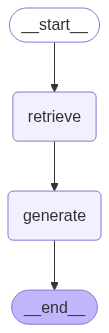

In [12]:
rag_graph

Let's test our chain out!

In [13]:
response = rag_graph.invoke({"question" : "Is applying for and securing a student loan in 2025 a terrible idea?"})

In [14]:
response["response"]

'The provided context does not contain specific information regarding whether applying for and securing a student loan in 2025 is a terrible idea. Therefore, I cannot determine or advise on that based solely on this information. \n\nIf you would like, you can rephrase your question or provide more details related to your financial situation or the pros and cons of student loans, and I will do my best to assist you.'

In [15]:
for context in response["context"]:
  print("Context:")
  print(context.page_content[:100])
  print("----")

Context:
student to earn that number of credits. For instance, if your school has a baccalaureate program tha
----
Context:
You must confirm that the borrower meets the definition of eligible borrower by doing the following:
----
Context:
Regardless of the counseling methods your school uses, it must document that the student received en
----
Context:
Deadlines
The application processing cycle typically lasts 21 months, with the FAFSA form opening on
----


Let's see if it can handle a query that is totally unrelated to the source documents.

In [16]:
response = rag_graph.invoke({"question" : "What is the airspeed velocity of an unladen swallow?"})

In [17]:
response["response"]

'The provided context does not contain any information regarding the airspeed velocity of an unladen swallow. Please rephrase your question or provide more details if possible.'

## Task 3: Setting Up LangSmith

Now that we have a chain - we're ready to get started with LangSmith!

We're going to go ahead and use the following `env` variables to get our Colab notebook set up to start reporting.

If all you needed was simple monitoring - this is all you would need to do!

### LangSmith API

In order to use LangSmith - you will need an API key. You can sign up for a free account on [LangSmith's homepage!](https://www.langchain.com/langsmith)

Once you have created your account, Take the navigation option for `Settings` then `API Keys` to create an API key.

In [18]:
os.environ["LANGSMITH_API_KEY"] = getpass.getpass('Enter your LangSmith API key: ')

Let's test our our first generation!

In [25]:
from uuid import uuid4

unique_id = uuid4().hex[0:8]
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = f"LangSmith - {unique_id}"

from langchain.callbacks import LangChainTracer
from langchain.schema.runnable import RunnableConfig
tracer = LangChainTracer(project_name=os.environ["LANGSMITH_PROJECT"])
config = {
    "tags" : ["Demo Run"],
    "callbacks": [tracer]
}

rag_graph.invoke({"question" : "What is the maximum loan amount I can get from the government to go to school these days?"}, config)['response']

Response: {'question': 'What is the maximum loan amount I can get from the government to go to school these days?', 'context': [Document(metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'wkhtmltopdf 0.12.6', 'creationdate': "D:20250605165703Z00'00'", 'source': 'data/The_Direct_Loan_Program.pdf', 'file_path': 'data/The_Direct_Loan_Program.pdf', 'total_pages': 71, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': "D:20250605165703Z00'00'", 'trapped': '', 'modDate': "D:20250605165703Z00'00'", 'creationDate': "D:20250605165703Z00'00'", 'page': 69, '_id': '01cd5bc7acd74851a988678c512219e6', '_collection_name': 'c3ae26e18222495ea247719e6385eb87'}, page_content='program. Therefore, the maximum loan amount the student may receive for the program at School B (for the\nabbreviated loan period and any subsequent loan period combined) is a total of $1,815, not more than $1,155 of\nwhich may be subsidized (the prorated loan limits for the program).

## Task 4: Examining the Trace in LangSmith!

Head on over to your LangSmith web UI to check out how the trace looks in LangSmith!

#### 🏗️ Activity #1:

Include a screenshot of your trace and explain what it means.

##### ✅ Answer:

I can see the trace created under the project LangSmith - 0fb86dd3. <br>
I can see all the steps it has followed, from the `retrieve` node to the `generate` node. <br>
<img src="screenshots/activity1_trace.png" alt="Alt text" width="1500"/>

From the `retrieve` node I can see the input question and the context retrieved from the Qdrant database.<br>
From the `generate` node I can also see the Question and the Context along with the Output / Response provided.<br>
For both I can see a lot of information about the trace like start / end time, status, total_tokens, latency, tags, etc<br>
There is a tab called Metadata which is showing the metadata related with the Graph like the environment variables, library versions, etc <br>
Also it is easy to identify if something has gone wrong because there is an Error field and in the trace logs it can be identified rapidly.



<img src="screenshots/act1_retrieve.png" alt="Alt text" width="1500"/>
<img src="screenshots/act1_generate.png" alt="Alt text" width="1500"/>


## Task 5: Loading Our Testing Set

In [21]:
!git clone https://github.com/AI-Maker-Space/DataRepository.git

Cloning into 'DataRepository'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 122 (delta 37), reused 39 (delta 10), pack-reused 8 (from 1)
Receiving objects: 100% (122/122), 78.04 MiB | 3.33 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [20]:
import pandas as pd

test_df = pd.read_csv("DataRepository/student_loan_rag_test_data.csv")
print(test_df.columns.to_list())

['Unnamed: 0', 'question', 'context', 'answer', 'idx']


Now we can set up our LangSmith client - and we'll add the above created dataset to our LangSmith instance!

> NOTE: Read more about this process [here](https://docs.smith.langchain.com/old/evaluation/faq/manage-datasets#create-from-list-of-values)

In [21]:
from langsmith import Client

client = Client()

dataset_name = "langsmith-student-loan-rag-test"

dataset = client.create_dataset(
    dataset_name=dataset_name, description="Student Loan RAG Test Questions"
)

for triplet in test_df.iterrows():
  triplet = triplet[1]
  client.create_example(
      inputs={"question" : triplet["question"], "context": triplet["context"]},
      outputs={"answer" : triplet["answer"]},
      dataset_id=dataset.id
  )

## Task 6: Evaluation

Now we can run the evaluation!

We'll need to start by preparing some custom data preparation functions to ensure our chain works with the expected inputs/outputs from the `evaluate` process in LangSmith.

> NOTE: More reading on this available [here](https://docs.smith.langchain.com/how_to_guides/evaluation/evaluate_llm_application#evaluate-a-langchain-runnable)

In [54]:
def prepare_data_ref(run, example):
  return {
      "prediction" : run.outputs["response"],
      "reference" : example.outputs["answer"],
      "input" : example.inputs["question"]
  }

def prepare_data_noref(run, example):
  return {
      "prediction" : run.outputs["response"],
      "input" : example.inputs["question"]
  }

def prepare_context_ref(run, example):
  return {
      "prediction" : run.outputs["response"],
      "reference" : example.inputs["context"],
      "input" : example.inputs["question"]
  }

We'll be using a few custom evaluators to evaluate our pipeline, as well as a few "built in" methods!

Check out the built-ins [here](https://docs.smith.langchain.com/reference/sdk_reference/langchain_evaluators)!

In [82]:
from langsmith.evaluation import LangChainStringEvaluator, evaluate

eval_llm = ChatOpenAI(model="gpt-4o-mini", tags=["eval_llm"])

cot_qa_evaluator = LangChainStringEvaluator("cot_qa",  config={"llm":eval_llm}, prepare_data=prepare_context_ref)

unlabeled_dopeness_evaluator = LangChainStringEvaluator(
    "criteria",
    config={
        "criteria" : {
            "dopeness" : "Is the answer to the question dope, meaning cool - awesome - and legit?"
        },
        "llm" : eval_llm,
    },
    prepare_data=prepare_data_noref
)

labeled_score_evaluator = LangChainStringEvaluator(
    "labeled_score_string",
    config={
        "criteria": {
            "accuracy": "Is the generated answer the same as the reference answer?"
        },
    },
    prepare_data=prepare_data_ref
)

base_rag_results = evaluate(
    rag_graph.invoke,
    data=dataset_name,
    evaluators=[
        cot_qa_evaluator,
        unlabeled_dopeness_evaluator,
        labeled_score_evaluator,
        ],
    experiment_prefix="Base RAG Evaluation"
)

View the evaluation results for experiment: 'Base RAG Evaluation-825ca644' at:
https://smith.langchain.com/o/c21c7da9-346c-4a28-b19c-bb6d2faffe60/datasets/27faff8c-559a-48be-bf58-039beff4b6b6/compare?selectedSessions=122c0a33-2624-4715-8166-e74308056189




0it [00:00, ?it/s]

v#### ❓Question #1:

What conclusions can you draw about the above results?

Describe in your own words what the metrics are expressing.


##### ✅ Answer:


The screenshots below show that the results obtained for the `CoT Contextual Accuracy`are excellents. All of them are CORRECT which means that the model is reasoning well and its answers are correct according to the context and reference.

The results obtained for the `Score_string: Accuracy` are between 10 and 6 (10 in most cases) which means that the generated responses are very similar or equal to the reference.

The results obtained for the `Dopeness` are not good, only 4 Y from 23 experiments, which means that the model response is not clear, natural or useful according to the evaluator.

In summary we can conclude that the model is working fine, answering the questions correctly and accurately, using appropriate context, but can improve the way of communicating.
The responses may be too technical, unnatural, long, short, or not well-structured for an end user.

One way we could use to improve the `Dopeness` could be improving the prompt.
Making the prompt more conversational, asking for summaries or examples, requesting structure, avoiding unnecessary repetitions or technicalities.

<img src="screenshots/datasets_and_experiments_01.png" alt="Alt text" width="1500"/>
<img src="screenshots/datasets_and_experiments_02.png" alt="Alt text" width="1500"/>

<br>

 - The screenshots below are for the first question evaluated : <b>What does 'verification' mean in the FAFSA process?</b>

  - `Cot Contextual Accuracy`: In this screenshot we can see the steps followed by the model to evaluate the response CoT accuracy and the score provided :
 <img src="screenshots/cot.png" alt="Alt text" width="1500"/>

 <br>

  - `Score_string : Accuracy`: In this screenshot we can see the steps followed by the model to evaluate the response accuracy and the score provided :
  <img src="screenshots/accuracy.png" alt="Alt text" width="1500"/>

 <br>

   - `Dopeness`: In this screenshot we can see the steps followed by the model to evaluate the dopeness and the score provided :
   <img src="screenshots/dopeness.png" alt="Alt text" width="1500"/>